In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from moabb.paradigms import P300
from moabb.datasets import *


paradigm = P300(resample=48)
dataset = BNCI2014008()
epochs, labels, meta = paradigm.get_data(
    dataset=dataset, 
     subjects=[1],
     return_epochs=True
)
session = meta['session'][1]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]



BNCI2014008 has been renamed to BNCI2014_008. BNCI2014008 will be removed in version 1.1.
The dataset class name 'BNCI2014008' must be an abbreviation of its code 'BNCI2014-008'. See moabb.datasets.base.is_abbrev for more information.
/usr/local/lib/python3.10/dist-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 4200 events (all good), 0 – 1 s (baseline off), ~65.9 MB, data loaded,
 'Target': 700
 'NonTarget': 3500>
  warn(f"warnEpochs {epochs}")


Adding metadata with 3 columns
Adding metadata with 3 columns
4200 matching events found
No baseline correction applied


/usr/local/lib/python3.10/dist-packages/moabb/paradigms/base.py:350: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


In [3]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

X = tl.tensor(epochs.get_data())
y = labels

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/5, random_state=42)

In [5]:
#%env PYTHONWARNINGS=error

In [14]:
from sklearn.model_selection import StratifiedKFold
from hoda.hoda import BTTDA, GreedyBTTDA, HODA, trunc_eigh
from hoda.cov import mode_scatter
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import  warnings
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFwe
from sklearn.preprocessing import StandardScaler
import warnings
from joblib import parallel_backend
from joblib import Parallel

bttda = BTTDA(
    ranks=[1]*128,
    hoda_params=dict(
        rank=None,
        max_iter=64,
        tol=1e-8,
        init ='random',
        shrinkage='lw',
        toeplitz=None,
        obj='tr',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=True,
        random_state=42,
        delta=None,
       
    ),
    verbose=True,
    extra_train_info=True,

)
bttda.fit(X_train,y_train)

Fitting block 1/128...


Forward model :  64%|██████▍   | 41/64 [00:00<00:00, 345.19it/s]


Fitting block 2/128...


Forward model :  11%|█         | 7/64 [00:00<00:00, 317.13it/s]


Fitting block 3/128...


...

Fitting block 127/128...


Forward model :  16%|█▌        | 10/64 [00:00<00:00, 273.75it/s]


Fitting block 128/128...


Forward model :  23%|██▎       | 15/64 [00:00<00:00, 280.29it/s]


BTTDA(extra_train_info=True,
      hoda_params={'delta': None, 'extra_train_info': False, 'init': 'random',
                   'max_iter': 64, 'obj': 'tr', 'random_state': 42, 'rank': 1,
                   'shrinkage': 'lw', 'solver': 'lanczos', 'taper': False,
                   'toeplitz': None, 'tol': 1e-08, 'verbose': True},
      ranks=[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
             1, 1, 1, 1, 1, 1, 1, 1, ...],
      verbose=True)

In [15]:
import pandas as pd
df = pd.DataFrame(bttda.train_info_)
df

,block,rank,F_tr,F_rt,log_loss,mse,nmse
0,1,"(1, 1)",0.000120,0.000240,0.349098,1.060264e-10,0.998975
1,2,"(1, 1)",0.000120,0.000241,0.349085,1.059515e-10,0.998269
2,3,"(1, 1)",0.000102,0.000293,0.330173,1.058421e-10,0.997238
3,4,"(1, 1)",0.000092,0.000293,0.330163,1.058207e-10,0.997037
4,5,"(1, 1)",0.000078,0.000340,0.316046,1.056810e-10,0.995721
...,...,...,...,...,...,...,...
123,124,"(1, 1)",0.000017,0.000450,0.282341,7.769565e-11,0.732044
124,125,"(1, 1)",0.000017,0.000450,0.282310,7.718315e-11,0.727215
125,126,"(1, 1)",0.000016,0.000450,0.282267,7.669366e-11,0.722603
126,127,"(1, 1)",0.000016,0.000450,0.282244,7.659122e-11,0.721638


<Axes: xlabel='block', ylabel='nmse'>

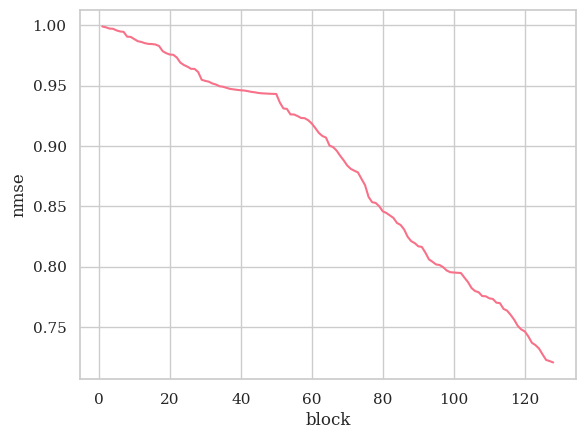

In [16]:
import seaborn as sns
sns.lineplot(data=df, x='block', y='nmse')

,mse,nmse,block
0,1.092878e-10,0.999644,0
1,1.092575e-10,0.999368,1
2,1.091491e-10,0.998376,2
3,1.091272e-10,0.998175,3
4,1.089678e-10,0.996718,4
...,...,...,...
123,8.095275e-11,0.740467,123
124,8.035072e-11,0.734960,124
125,7.984832e-11,0.730364,125
126,7.976600e-11,0.729611,126


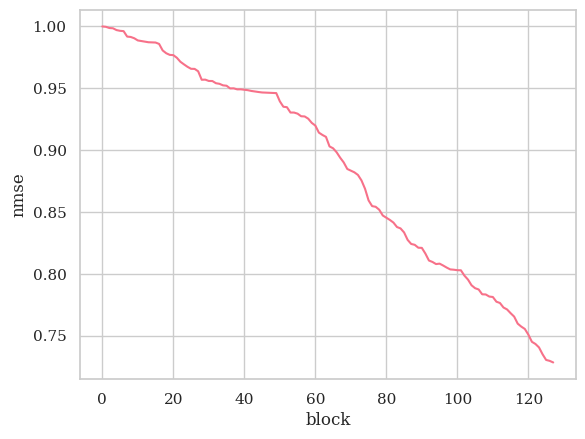

In [17]:
from hoda.hoda import forward_stats
info = []
for b in range(len(bttda.blocks_)):
    Xt_test = bttda.transform(X_test, blocks=bttda.blocks_[:b+1])
    X_rec_test = bttda.inv_transform(Xt_test, n_blocks=b+1)
    res = forward_stats(X_test, Xt_test, X_rec_test,y)
    res['block'] =b
    info.append(res)
info = pd.DataFrame(info)
sns.lineplot(data=info, x='block', y='nmse')
info